# Exercice 1

In [1]:
import pandas as pd
import numpy as np
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv('painters.csv', index_col = 0)
print(df.head())
print(df.describe())

            Composition  Drawing  Colour  Expression School
Da Udine             10        8      16           3      A
Da Vinci             15       16       4          14      A
Del Piombo            8       13      16           7      A
Del Sarto            12       16       9           8      A
Fr. Penni             0       15       8           0      A
       Composition    Drawing     Colour  Expression
count    54.000000  54.000000  54.000000   54.000000
mean     11.555556  12.462963  10.944444    7.666667
std       4.087102   3.457084   4.651706    4.797798
min       0.000000   6.000000   0.000000    0.000000
25%       8.250000  10.000000   7.250000    4.000000
50%      12.500000  13.500000  10.000000    6.000000
75%      15.000000  15.000000  16.000000   11.500000
max      18.000000  18.000000  18.000000   18.000000


In [3]:
df_numeric = df.drop('School', axis = 1)
scaler = StandardScaler()
df_scaled = scaler.fit_transform(df_numeric)
df_scaled

array([[-0.38417491, -1.3030835 ,  1.0970227 , -0.98180162],
       [ 0.85067301,  1.03273423, -1.50689931,  1.33244506],
       [-0.87811408,  0.15680258,  1.0970227 , -0.14025737],
       [ 0.10976426,  1.03273423, -0.42193181,  0.07012869],
       [-2.85387076,  0.74075701, -0.63892531, -1.61295981],
       [ 0.85067301,  1.03273423, -1.50689931,  1.33244506],
       [-0.87811408,  1.32471144, -1.50689931,  0.07012869],
       [ 0.85067301,  1.03273423, -0.85591881, -0.35064344],
       [-1.86599242, -0.13517464, -0.20493831, -0.77141556],
       [ 1.34461218,  1.61668866,  0.2290487 ,  2.17398931],
       [-0.38417491,  0.15680258, -0.63892531,  0.07012869],
       [ 0.35673384,  0.74075701, -0.63892531,  0.07012869],
       [-0.38417491,  0.74075701, -1.07291231, -0.35064344],
       [ 0.85067301,  0.44877979, -0.85591881,  0.49090081],
       [ 0.35673384,  0.44877979, -0.20493831,  0.28051475],
       [ 0.10976426,  0.74075701, -1.28990581,  0.07012869],
       [ 0.60370343,  0.

In [4]:
pca = PCA()
components = pca.fit_transform(df_scaled)
components_df = pd.DataFrame(data = components,
                             columns = [f'PC{i + 1}' for i in range(len(df_numeric.columns))],
                             index = df.index)
components_df.head()

,PC1,PC2,PC3,PC4
Da Udine,1.856985,-0.697090,0.247333,0.132324
Da Vinci,-2.280215,0.597597,0.301511,-0.434660
Del Piombo,0.815286,-0.322183,-1.114869,0.085887
Del Sarto,-0.818842,0.529064,-0.353240,0.431675
Fr. Penni,1.691339,2.598880,-1.419590,0.270410


In [6]:
print("Variance of each component (%):", pca.explained_variance_ratio_ * 100)
print("Total variance explained (%):", sum(pca.explained_variance_ratio_) * 100)
np.cumsum(pca.explained_variance_ratio_)

Variance of each component (%): [56.89838698 25.9924857   9.85058255  7.25854478]
Total variance explained (%): 99.99999999999997


array([0.56898387, 0.82890873, 0.92741455, 1.        ])

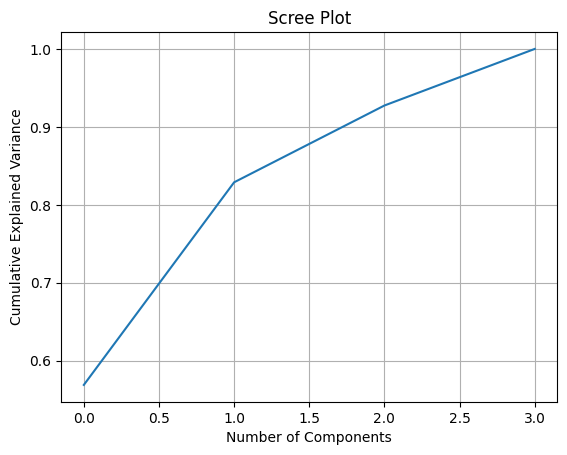

In [7]:
plt.plot(np.cumsum(pca.explained_variance_ratio_))
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance')
plt.title('Scree Plot')
plt.grid(True)
plt.show()

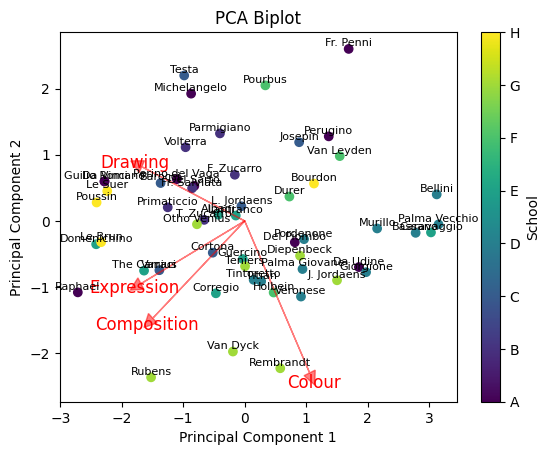

In [8]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
components_df['School_cat'] = le.fit_transform(df['School'])

scatter = plt.scatter(components_df['PC1'],
                      components_df['PC2'],
                      c = components_df['School_cat'],
                      cmap = 'viridis')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.title('PCA Biplot')
cbar = plt.colorbar(scatter)
cbar.set_label('School')
cbar.set_ticks(np.arange(len(np.unique(components_df['School_cat']))))
cbar.set_ticklabels(le.classes_)

for i, colname in enumerate(df_numeric.columns):
    plt.arrow(0, 0, pca.components_[0, i] * 3, pca.components_[1, i] * 3,
              color = 'red',
              alpha = 0.5,
              head_width = 0.2,
              head_length = 0.2)
    plt.text(pca.components_[0, i] * 3.2, pca.components_[1, i] * 3.2, colname,
             color = 'red',
             ha = 'center',
             va = 'center',
             fontsize = 12)

for i, txt in enumerate(components_df.index):
    plt.annotate(txt, (components_df['PC1'][i], components_df['PC2'][i]),
                 textcoords = "offset points",
                 xytext=(0, 2),
                 fontsize = 8,
                 ha='center')

In [11]:
from plotnine import ggplot, aes, geom_point, geom_text, labs, theme_minimal
components_df['School'] = df['School']
components_df['Name'] = df.index

print(components_df.head())

                 PC1       PC2       PC3       PC4  School_cat School  \
Da Udine    1.856985 -0.697090  0.247333  0.132324           0      A   
Da Vinci   -2.280215  0.597597  0.301511 -0.434660           0      A   
Del Piombo  0.815286 -0.322183 -1.114869  0.085887           0      A   
Del Sarto  -0.818842  0.529064 -0.353240  0.431675           0      A   
Fr. Penni   1.691339  2.598880 -1.419590  0.270410           0      A   

                  Name  
Da Udine      Da Udine  
Da Vinci      Da Vinci  
Del Piombo  Del Piombo  
Del Sarto    Del Sarto  
Fr. Penni    Fr. Penni  


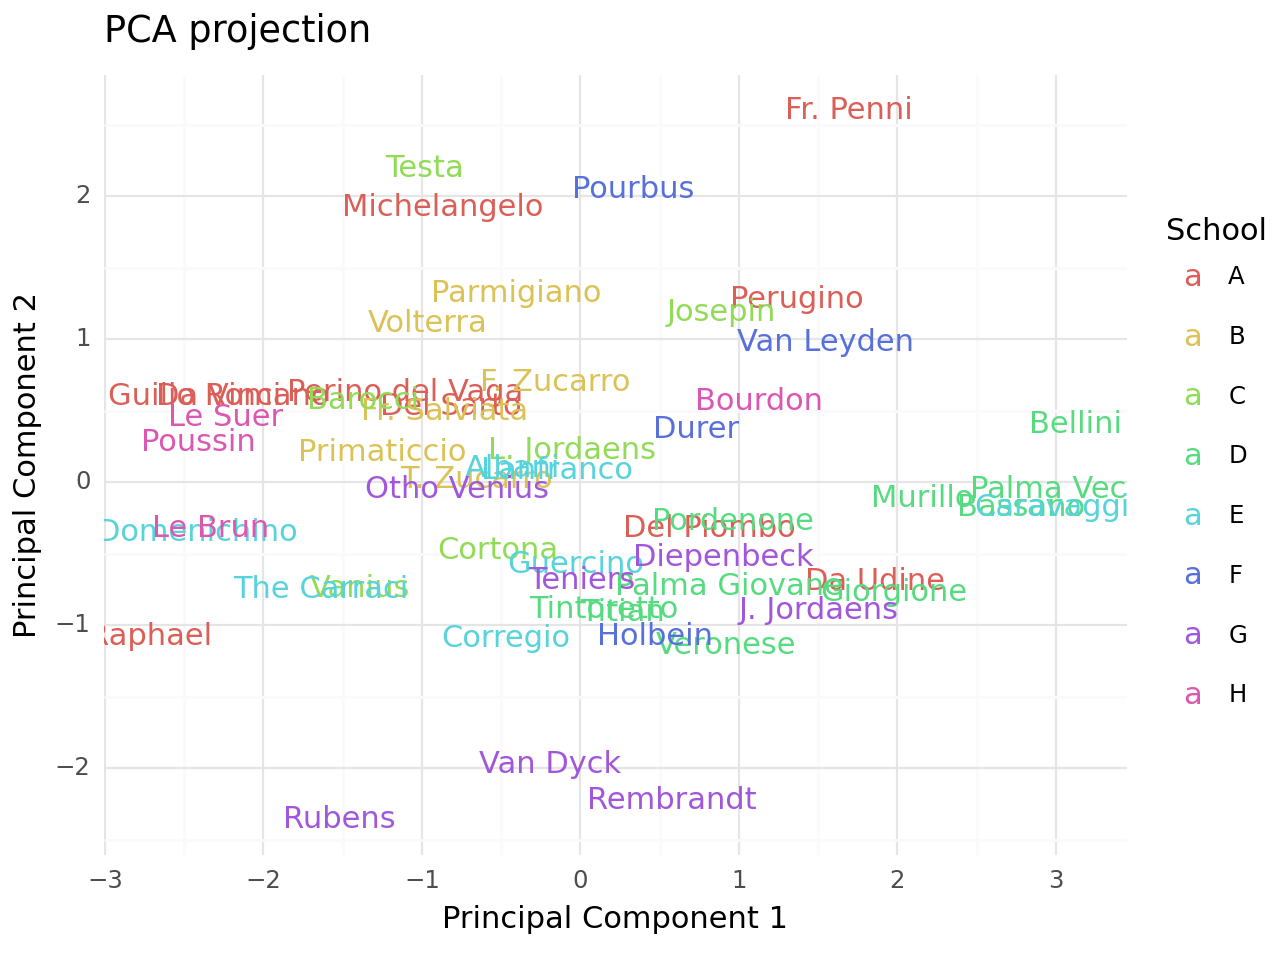

<Figure Size: (640 x 480)>

In [13]:
(
    ggplot(components_df,
           aes(x = 'PC1',
               y = 'PC2',
               color = 'School',
               label = 'Name'))
    #+geom_point(aes())
    +geom_text()
    +labs(title = 'PCA projection',
         x = 'Principal Component 1',
         y = 'Principal Component 2')
    +theme_minimal()
)

# Exercice 2

In [14]:
df = pd.read_csv('swiss.csv', index_col = 0)
df.index.name = 'Region'
print(df.head())
print(df.describe())

              Fertility  Agriculture  Examination  Education  Catholic  \
Region                                                                   
Courtelary         80.2         17.0           15         12      9.96   
Delemont           83.1         45.1            6          9     84.84   
Franches-Mnt       92.5         39.7            5          5     93.40   
Moutier            85.8         36.5           12          7     33.77   
Neuveville         76.9         43.5           17         15      5.16   

              Infant.Mortality  
Region                          
Courtelary                22.2  
Delemont                  22.2  
Franches-Mnt              20.2  
Moutier                   20.3  
Neuveville                20.6  
       Fertility  Agriculture  Examination  Education   Catholic  \
count  47.000000    47.000000    47.000000  47.000000   47.00000   
mean   70.142553    50.659574    16.489362  10.978723   41.14383   
std    12.491697    22.711218     7.977883   9

In [15]:
from sklearn.manifold import MDS
mds = MDS(n_components = 2,
          dissimilarity = 'euclidean')
mds_coords = mds.fit_transform(df)

/usr/local/lib/python3.10/dist-packages/sklearn/manifold/_mds.py:299: FutureWarning: The default value of `normalized_stress` will change to `'auto'` in version 1.4. To suppress this warning, manually set the value of `normalized_stress`.


In [16]:
df_mds = pd.DataFrame(mds_coords,
                  columns = ['V1', 'V2'],
                  index = df.index).reset_index()
print(df_mds)

          Region         V1         V2
0     Courtelary  43.546467  15.573884
1       Delemont -19.889440 -41.692882
2   Franches-Mnt -20.107036 -56.337623
3        Moutier   9.718414  -0.693563
4     Neuveville  23.441131  28.260074
5     Porrentruy -12.701317 -51.559737
6          Broye -43.019277 -36.497734
7          Glane -43.702367 -46.589479
8        Gruyere -32.252044 -48.701344
9         Sarine -21.483785 -47.500763
10       Veveyse -41.423204 -46.673301
11         Aigle   5.104659  33.109822
12       Aubonne   2.276841  43.070976
13      Avenches   8.208171  38.083548
14      Cossonay   2.689781  45.764334
15     Echallens -12.717419  25.782615
16      Grandson  31.489155  28.199662
17      Lausanne  48.214585   5.496005
18     La Vallee  57.052950  19.556777
19        Lavaux  -1.541583  45.848773
20        Morges   9.504822  36.629007
21        Moudon  12.386392  36.671470
22         Nyone  13.033384  22.161169
23          Orbe  15.954298  38.094278
24          Oron  -5.1894

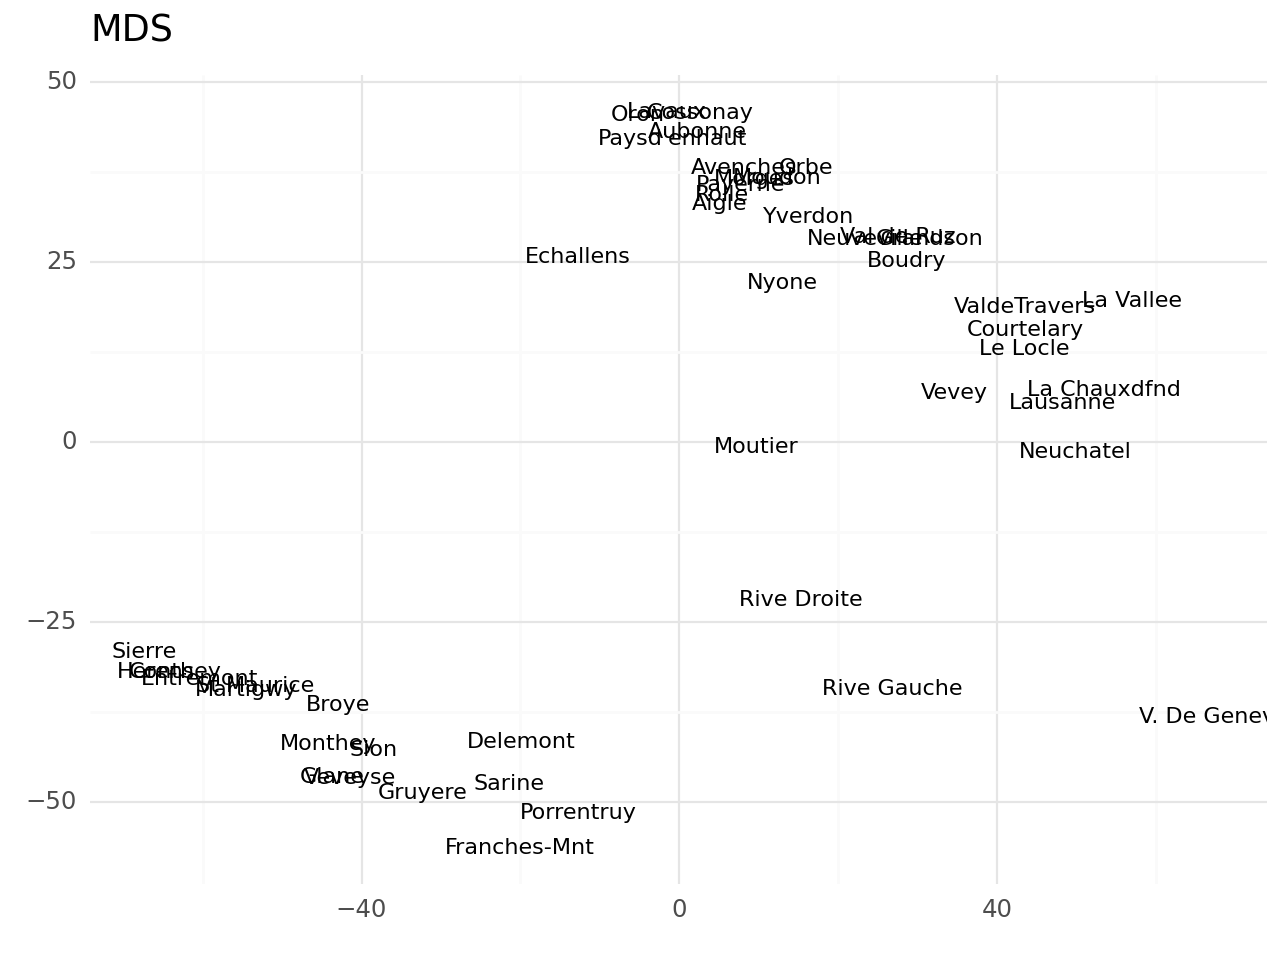

<Figure Size: (640 x 480)>

In [17]:
from plotnine import ggplot, aes, geom_text, labs, theme_minimal

# Plot
(
    ggplot(df_mds,
           aes(x = 'V1',
               y = 'V2',
               label = 'Region'))
    +geom_text(size = 8)
    +labs(title = 'MDS',
         x = '',
         y = '')
    +theme_minimal()
)